# Notebook 08 - AI Analyst Assistant and Opportunity Modeling

This notebook implements an AI-inspired analyst assistant that answers Airbnb market questions using DuckDB SQL and a lightweight machine learning component to identify high-opportunity listing segments.

In [1]:
import pandas as pd
import numpy as np
import duckdb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
master_dataset = pd.read_csv(
    "../data/processed/pipeline_master_dataset.csv"
)

print(master_dataset.shape)

master_dataset.head()

C:\Users\Sagar\AppData\Local\Temp\ipykernel_25540\2442259338.py:1: DtypeWarning: Columns (0: neighborhood_overview, 1: host_since, 2: host_response_time, 3: host_response_rate, 4: host_acceptance_rate, 5: host_thumbnail_url, 6: host_neighbourhood, 7: host_verifications, 8: neighbourhood, 9: neighbourhood_group_cleansed, 10: license, 11: instant_bookable, 12: host_profile_url, 13: price_quote_checkin_date, 14: price_quote_checkout_date, 15: price_quote_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  master_dataset = pd.read_csv(


(131907, 103)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,host_profile_url,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
features = [
    "occupancy_rate",
    "availability_rate",
    "total_reviews",
    "price_clean"
]

ai_dataset = (
    master_dataset[
        [
            "id",
            "city",
            "room_type",
            "property_type",
            "neighbourhood_cleansed"
        ] + features
    ]
    .copy()
)

ai_dataset = ai_dataset.dropna(
    subset=features
)

print(ai_dataset.shape)

(63460, 9)


In [4]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    ai_dataset[features]
)

scaled_features.shape

(63460, 4)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = model.fit_predict(
        scaled_features
    )

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(
            scaled_features,
            clusters
        )
    })

cluster_metrics = pd.DataFrame(results)

cluster_metrics

,k,inertia,silhouette_score
0,2,152868.444843,0.534016
1,3,105282.919754,0.536482
2,4,72918.460373,0.568761
3,5,59471.052288,0.456683
4,6,51531.022734,0.459507
5,7,43842.381994,0.470584
6,8,38542.891239,0.413466
7,9,33644.616635,0.436921
8,10,29294.967774,0.440811


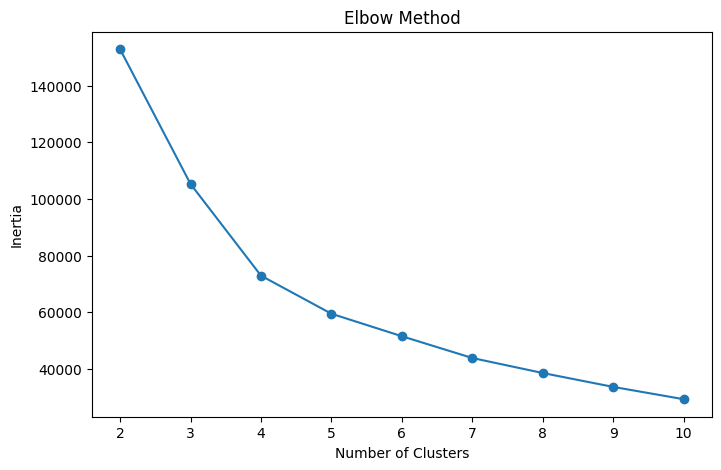

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_metrics["k"],
    cluster_metrics["inertia"],
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

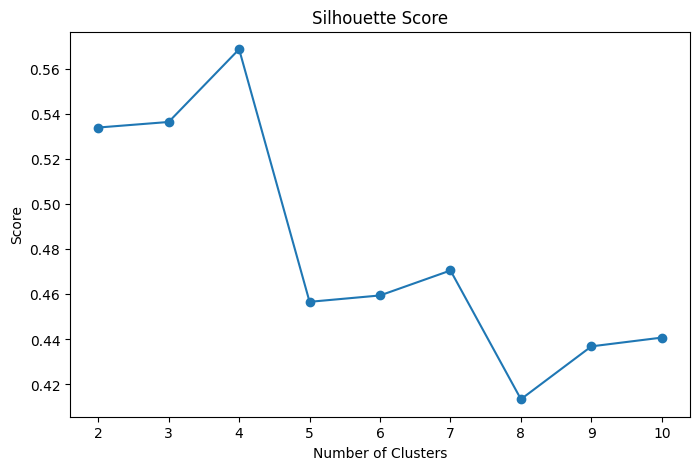

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_metrics["k"],
    cluster_metrics["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ai_dataset["cluster"] = kmeans.fit_predict(scaled_features)

# Add this — useful for interpreting clusters later
print("Cluster distribution:")
print(ai_dataset["cluster"].value_counts().sort_index())

Cluster distribution:
cluster
0    33692
1    26801
2       10
3     2957
Name: count, dtype: int64


In [10]:
cluster_summary = (
    ai_dataset
    .groupby("cluster")
    [
        [
            "occupancy_rate",
            "availability_rate",
            "total_reviews",
            "price_clean"
        ]
    ]
    .agg(["mean", "median"])
    .round(2)
)

cluster_summary

occupancy_rate        availability_rate        total_reviews         \
                  mean median              mean median          mean median   
cluster                                                                       
0                 0.16   0.13              0.84   0.87         25.83   11.0   
1                 0.74   0.76              0.26   0.24         28.52   14.0   
2                 0.19   0.14              0.81   0.86         55.70   62.0   
3                 0.43   0.40              0.57   0.60        291.48  248.0   

        price_clean           
               mean   median  
cluster                       
0            206.61    145.0  
1            180.28    133.0  
2          53287.70  55794.0  
3            158.98    113.0

In [11]:
ai_dataset[
    ai_dataset["cluster"] == 2
][
    [
        "city",
        "price_clean",
        "occupancy_rate",
        "total_reviews",
        "room_type",
        "property_type",
        "neighbourhood_cleansed"
    ]
].sort_values(
    by="price_clean",
    ascending=False
)

,city,price_clean,occupancy_rate,total_reviews,room_type,property_type,neighbourhood_cleansed
10228,London,74100.0,0.498630,83.0,Entire home/apt,Entire rental unit,Islington
77023,London,66189.0,0.021918,3.0,Private room,Private room in rental unit,Lambeth
54442,London,65000.0,0.260274,53.0,Private room,Private room in rental unit,Lambeth
75312,London,58000.0,0.021918,5.0,Private room,Private room in rental unit,Lambeth
57204,London,58000.0,0.263014,71.0,Private room,Private room in rental unit,Lambeth
9489,London,53588.0,0.509589,97.0,Private room,Private room in rental unit,Kensington and Chelsea
38591,London,50000.0,0.000000,127.0,Private room,Private room in condo,Lambeth
51162,London,50000.0,0.021918,89.0,Private room,Private room in rental unit,Lambeth
69658,London,30000.0,0.000000,18.0,Private room,Private room in rental unit,Lambeth
69137,London,28000.0,0.276712,11.0,Private room,Private room in rental unit,Lambeth


In [13]:
ai_dataset["price_clean"].describe(
    percentiles=[0.95, 0.99, 0.999]
)

count    63460.000000
mean       201.635660
std        769.416167
min          4.470000
95%        487.000000
99%        999.000000
99.9%     4312.033500
max      74100.000000
Name: price_clean, dtype: float64

In [14]:
clustering_dataset = ai_dataset[
    ai_dataset["price_clean"]
    <= ai_dataset["price_clean"].quantile(0.999)
].copy()

print(clustering_dataset.shape)

(63396, 10)


In [15]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    clustering_dataset[
        [
            "occupancy_rate",
            "availability_rate",
            "total_reviews",
            "price_clean"
        ]
    ]
)

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = model.fit_predict(
        scaled_features
    )

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(
            scaled_features,
            clusters
        )
    })

cluster_metrics = pd.DataFrame(results)

cluster_metrics

,k,inertia,silhouette_score
0,2,152610.390190,0.459787
1,3,120200.049352,0.485163
2,4,91690.004042,0.505409
3,5,78648.359314,0.375063
4,6,68958.403873,0.384151
5,7,61451.485739,0.391250
6,8,56410.859706,0.366658
7,9,51536.335047,0.390348
8,10,46885.763034,0.348076


In [17]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clustering_dataset["cluster"] = kmeans.fit_predict(
    scaled_features
)

print(
    clustering_dataset["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    26087
1    32572
2     2881
3     1856
Name: count, dtype: int64


In [18]:
cluster_summary = (
    clustering_dataset
    .groupby("cluster")
    [
        [
            "occupancy_rate",
            "availability_rate",
            "total_reviews",
            "price_clean"
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,occupancy_rate,availability_rate,total_reviews,price_clean
cluster,,,,
0,0.75,0.25,28.82,156.17
1,0.16,0.84,26.03,167.89
2,0.43,0.57,294.13,144.25
3,0.35,0.65,25.89,989.92


In [19]:
segment_mapping = {
    0: "High Demand",
    1: "Low Performance",
    2: "Established Popular",
    3: "Premium Luxury"
}

clustering_dataset["segment"] = (
    clustering_dataset["cluster"]
    .map(segment_mapping)
)

clustering_dataset[
    ["cluster", "segment"]
].head()

,cluster,segment
0,1,Low Performance
1,0,High Demand
2,0,High Demand
4,1,Low Performance
5,1,Low Performance


In [20]:
clustering_dataset["segment"].value_counts()

segment
Low Performance        32572
High Demand            26087
Established Popular     2881
Premium Luxury          1856
Name: count, dtype: int64

In [21]:
print(clustering_dataset.shape)

print(
    clustering_dataset["segment"]
    .value_counts()
    .sum()
)

(63396, 11)
63396


In [23]:
segment_summary = (
    clustering_dataset
    .groupby("segment")
    [
        [
            "occupancy_rate",
            "total_reviews",
            "price_clean"
        ]
    ]
    .agg(
        {
            "occupancy_rate": "mean",
            "total_reviews": "mean",
            "price_clean": "mean"
        }
    )
    .round(2)
)

segment_summary

,occupancy_rate,total_reviews,price_clean
segment,,,
Established Popular,0.43,294.13,144.25
High Demand,0.75,28.82,156.17
Low Performance,0.16,26.03,167.89
Premium Luxury,0.35,25.89,989.92


In [24]:
segment_counts = (
    clustering_dataset["segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "segment",
    "listing_count"
]

segment_counts

,segment,listing_count
0,Low Performance,32572
1,High Demand,26087
2,Established Popular,2881
3,Premium Luxury,1856


In [25]:
segment_profile = (
    segment_summary
    .merge(
        segment_counts,
        on="segment"
    )
)

segment_profile

,segment,occupancy_rate,total_reviews,price_clean,listing_count
0,Established Popular,0.43,294.13,144.25,2881
1,High Demand,0.75,28.82,156.17,26087
2,Low Performance,0.16,26.03,167.89,32572
3,Premium Luxury,0.35,25.89,989.92,1856


In [26]:
segment_insights = {
    "High Demand":
        """
        Strong occupancy performance indicates consistent customer demand.
        Suitable for revenue optimization and dynamic pricing strategies.
        """,

    "Established Popular":
        """
        Significant review history demonstrates long-term customer trust
        and market acceptance.
        """,

    "Premium Luxury":
        """
        Premium pricing segment targeting higher-end travelers.
        Focus on exclusivity and luxury experience.
        """,

    "Low Performance":
        """
        Low occupancy suggests opportunities for pricing,
        marketing, or listing optimization improvements.
        """
}

In [27]:
def ai_opportunity_advisor(segment_name):

    row = segment_profile[
        segment_profile["segment"] == segment_name
    ].iloc[0]

    print("=" * 60)
    print(f"SEGMENT: {segment_name}")
    print("=" * 60)

    print(f"Listings           : {row['listing_count']:,}")
    print(f"Average Occupancy  : {row['occupancy_rate']:.2f}")
    print(f"Average Reviews    : {row['total_reviews']:.2f}")
    print(f"Average Price      : £{row['price_clean']:.2f}")

    print("\nBusiness Insight:")
    print(segment_insights[segment_name])

In [28]:
ai_opportunity_advisor("High Demand")

SEGMENT: High Demand
Listings           : 26,087
Average Occupancy  : 0.75
Average Reviews    : 28.82
Average Price      : £156.17

Business Insight:

        Strong occupancy performance indicates consistent customer demand.
        Suitable for revenue optimization and dynamic pricing strategies.
        


In [29]:
ai_opportunity_advisor("Premium Luxury")

SEGMENT: Premium Luxury
Listings           : 1,856
Average Occupancy  : 0.35
Average Reviews    : 25.89
Average Price      : £989.92

Business Insight:

        Premium pricing segment targeting higher-end travelers.
        Focus on exclusivity and luxury experience.
        


In [31]:
import duckdb

con = duckdb.connect()

In [32]:
con.register(
    "airbnb",
    master_dataset
)

In [33]:
con.sql("""
SELECT
    city,
    ROUND(AVG(occupancy_rate),3) AS avg_occupancy
FROM airbnb
GROUP BY city
ORDER BY avg_occupancy DESC
""").df()

,city,avg_occupancy
0,London,0.603
1,New York,0.570


In [34]:
analytics_questions = {

    "which city has highest occupancy":
    """
    SELECT
        city,
        ROUND(AVG(occupancy_rate),3) AS avg_occupancy
    FROM airbnb
    GROUP BY city
    ORDER BY avg_occupancy DESC
    """,

    "which city has highest price":
    """
    SELECT
        city,
        ROUND(AVG(price_clean),2) AS avg_price
    FROM airbnb
    GROUP BY city
    ORDER BY avg_price DESC
    """,

    "top expensive neighbourhoods":
    """
    SELECT
        city,
        neighbourhood_cleansed,
        ROUND(MEDIAN(price_clean),2) AS median_price
    FROM airbnb
    GROUP BY city, neighbourhood_cleansed
    ORDER BY median_price DESC
    LIMIT 10
    """,

    "most popular listings":
    """
    SELECT
        city,
        id,
        total_reviews,
        price_clean
    FROM airbnb
    ORDER BY total_reviews DESC
    LIMIT 10
    """
}

In [35]:
def ask_analytics(question):

    question = question.lower()

    if question in analytics_questions:

        result = con.sql(
            analytics_questions[question]
        ).df()

        print(f"\nQUESTION: {question}\n")

        return result

    else:

        print(
            "Question not supported."
        )

In [36]:
ask_analytics(
    "which city has highest occupancy"
)


QUESTION: which city has highest occupancy



,city,avg_occupancy
0,London,0.603
1,New York,0.570


In [37]:
ask_analytics(
    "top expensive neighbourhoods"
)


QUESTION: top expensive neighbourhoods



,city,neighbourhood_cleansed,median_price
0,New York,Fort Wadsworth,1010.33
1,New York,Battery Park City,609.91
2,New York,Tribeca,525.83
3,New York,NoHo,447.16
4,New York,SoHo,431.10
5,New York,Civic Center,414.00
6,New York,Hollis Hills,408.90
7,New York,Financial District,397.61
8,New York,Holliswood,395.64
9,New York,Greenwich Village,385.98


In [39]:
def ask_ai(question):

    question = question.lower()

    if "investment" in question or "opportunity" in question:
        ai_opportunity_advisor("High Demand")

    elif "luxury" in question or "premium" in question:
        ai_opportunity_advisor("Premium Luxury")

    elif "popular" in question or "established" in question:
        ai_opportunity_advisor("Established Popular")

    elif "underperform" in question or "low performance" in question:
        ai_opportunity_advisor("Low Performance")

    else:
        print("Question not supported yet.")
        print("Try:")
        print("- best investment opportunities")
        print("- show luxury market")
        print("- show established performers")
        print("- show underperforming listings")

In [40]:
ask_ai("best investment opportunities")

SEGMENT: High Demand
Listings           : 26,087
Average Occupancy  : 0.75
Average Reviews    : 28.82
Average Price      : £156.17

Business Insight:

        Strong occupancy performance indicates consistent customer demand.
        Suitable for revenue optimization and dynamic pricing strategies.
        


In [41]:
ask_ai("show luxury market")

SEGMENT: Premium Luxury
Listings           : 1,856
Average Occupancy  : 0.35
Average Reviews    : 25.89
Average Price      : £989.92

Business Insight:

        Premium pricing segment targeting higher-end travelers.
        Focus on exclusivity and luxury experience.
        


In [42]:
clustering_dataset.to_csv(
    "../data/curated/ai_segmented_listings.csv",
    index=False
)

segment_profile.to_csv(
    "../data/curated/ai_segment_profile.csv",
    index=False
)